**PERCOBAAN/LANGKAH PRAKTIKUM**

In [1]:
!pip install fuzzy-c-means

Import library dari Scikit-learn library

In [2]:
import pandas as pd
from fcmeans import FCM
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt
from seaborn import scatterplot as scatter

Percobaan menggunakan data artificial

In [ ]:
n_samples = 50
n_bins = 3
centers = [(-5, -5), (0, 0), (5, 5)]

x, _ = make_blobs(
    n_samples=n_samples,
    n_features=2,
    cluster_std=1.0,
    centers=centers,
    shuffle=False,
    random_state=42
    )


Menampilkan sebaran data dalam bentuk grafik

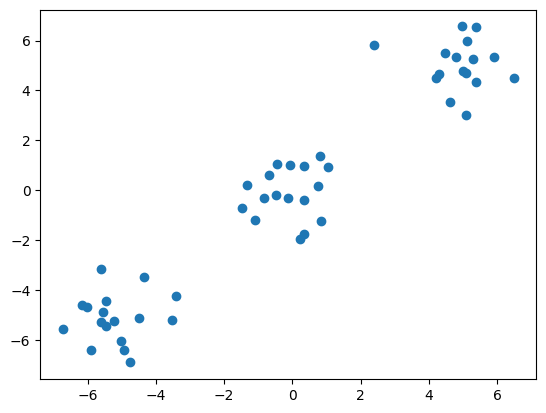

In [ ]:
plt.scatter(x[:,0],
x[:,1])
plt.show()

Jalankan metode fuzzy c-mean untuk pengelompokan data

In [ ]:
fcm = FCM(n_clusters=3)
fcm.fit(x)

Menghitung nilai pusat cluster dengan FCM

In [ ]:
fcm_centers = fcm.centers
fcm_centers

array([[-0.13111983, -0.08186128],
       [ 4.93178695,  5.02924427],
       [-5.22490759, -5.1678988 ]])

Label hasil pengelompokkan

In [ ]:
fcm_labels = fcm.u.argmax(axis=1)

Visualisasi hasil clustering

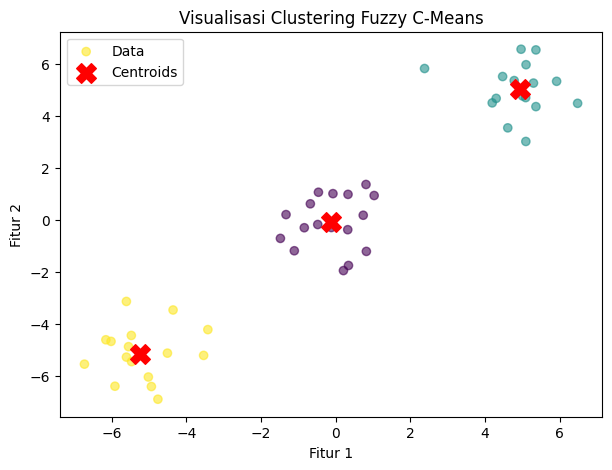

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    x[:, 0], x[:, 1],
    c=fcm_labels,
    cmap='viridis',
    alpha=0.6,
    label="Data"
)

plt.scatter(
    fcm_centers[:, 0],
    fcm_centers[:, 1],
    marker='X',
    s=200,
    c='red',
    label='Centroids'
)

plt.title("Visualisasi Clustering Fuzzy C-Means")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.legend()
plt.show()

**TUGAS**

Menggunakan data klas

In [3]:
df = pd.read_excel('DATA_klas.xlsx')

Menampilkan data

In [4]:
print(df.head())

   no            Nama  Mtt  Fisika  kimia  biologi  sejarah  akuntasi  \
0   1    Anis Fadilah   79      75     75       85       76        78   
1   2   Didik Mulyana   84      76     79       77       76        77   
2   3   Eka Dwi Utami   77      84     78       85       92        89   
3   4  Fandik Lasmana   78      86     84       77       78        77   
4   5  Putri Khadijah   82      82     81       91       90        82   

   Sosiologi  geografi  
0         76        80  
1         75        81  
2         77        82  
3         75        75  
4         79        91  


pilih hanya kolom numerik

In [6]:
import numpy as np

dk = df.select_dtypes(include=[np.number])

Menampilkan sebaran data

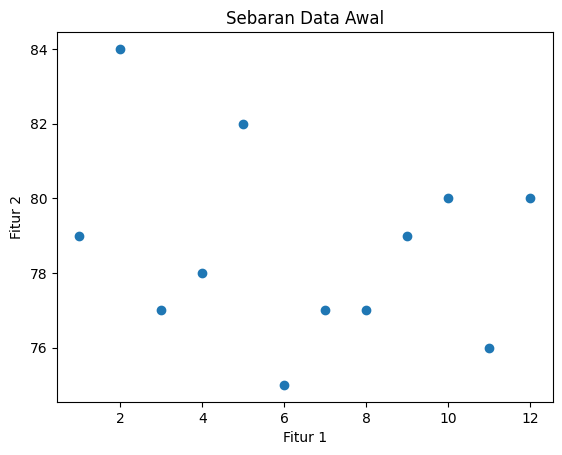

In [7]:
plt.scatter(dk.iloc[:,0], dk.iloc[:,1])
plt.title("Sebaran Data Awal")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

Jalankan metode fuzzy c-mean untuk pengelompokan data

In [8]:
fcm = FCM(n_clusters=3)
fcm.fit(dk.values)

Menghitung nilai pusat cluster dengan FCM

In [9]:
fcm_centers = fcm.centers
fcm_centers

array([[ 4.06897817, 79.49019467, 82.83754407, 79.53732607, 87.57598938,
        90.24913292, 85.0112159 , 77.88967749, 86.06946515],
       [ 5.64054007, 78.20118456, 76.07015429, 75.10124951, 83.58162474,
        77.25018238, 78.76562471, 76.12645315, 77.46907715],
       [ 8.9629954 , 78.87590558, 75.65434266, 74.80317424, 76.97520869,
        76.64821616, 78.38179646, 76.77396113, 79.8849777 ]])

Label hasil pengelompokkan

In [10]:
fcm_labels = fcm.u.argmax(axis=1)
print(fcm_labels)

[1 2 0 1 0 1 1 2 1 2 2 2]


Tambahkan label cluster ke dalam dataframe

In [11]:
df['Cluster'] = fcm_labels

Visualisasi hasil clustering

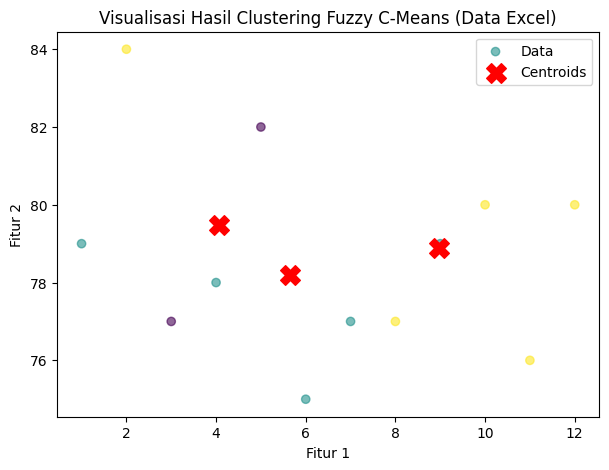

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(dk.iloc[:, 0], dk.iloc[:, 1], c=fcm_labels, cmap='viridis', alpha=0.6, label='Data')
plt.scatter(fcm_centers[:, 0], fcm_centers[:, 1],
            marker='X', s=200, c='red', label='Centroids')

plt.title("Visualisasi Hasil Clustering Fuzzy C-Means (Data Excel)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.legend()
plt.show()

Menggunakan data parfume

In [13]:
dc = pd.read_excel('perfume_data.xlsx')

Menampilkan data

In [14]:
print(dc.head())

      ajayeb  64558  64556  64543  64543.1  64541  64543.2  64543.3  64541.1  \
0      ajmal  60502  60489  61485    60487  61485    61513    60515    60500   
1     amreaj  57040  57040  57040    58041  58041    58041    58041    57042   
2       aood  71083  72087  71091    71095  71099    72103    71099    72099   
3  asgar_ali  68209  68209  68216    68216  68223    68223    68223    68223   
4    bukhoor  71046  71046  71046    71046  71046    71046    71046    71046   

   64541.2  ...  64541.8  64541.9  64541.10  64541.11  64541.12  64541.13  \
0    60500  ...    60472    60472     60461     61470     60487     60487   
1    57042  ...    58041    58041     58041     58041     58041     58041   
2    72099  ...    72095    71095     71095     72103     71103     71103   
3    68230  ...    68230    67224     67217     67217     68223     68223   
4    71046  ...    70049    70049     70049     70048     70049     70048   

   64528.2  64528.3  64528.4  64528.5  
0    61485    60

pilih hanya kolom numerik

In [15]:
import numpy as np

dk = dc.select_dtypes(include=[np.number])

Menampilkan sebaran data

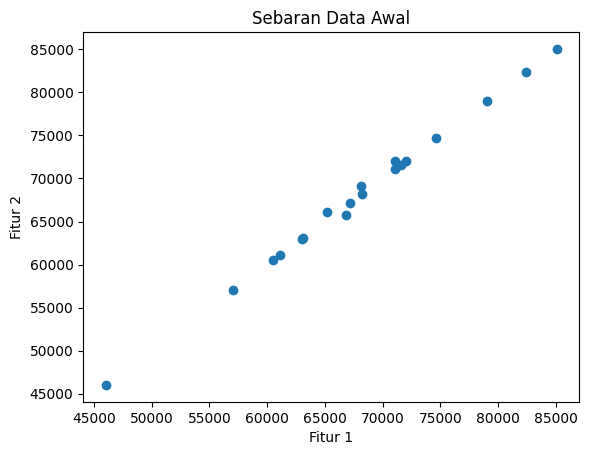

In [16]:
plt.scatter(dk.iloc[:,0], dk.iloc[:,1])
plt.title("Sebaran Data Awal")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

Jalankan metode fuzzy c-mean untuk pengelompokan data

In [17]:
fcm = FCM(n_clusters=3)
fcm.fit(dk.values)

Menghitung nilai pusat cluster dengan FCM

In [18]:
fcm_centers = fcm.centers
fcm_centers

array([[81839.34408984, 81837.43071397, 81836.79354266, 81831.86843218,
        82137.44728878, 81834.18012691, 81850.65940309, 81857.40234983,
        82132.44889551, 81827.30733978, 81813.50683354, 81838.6630886 ,
        81841.15573498, 82121.63111136, 82126.1749697 , 81820.28705156,
        81817.33471132, 82119.39059852, 82119.76462695, 81815.07206044,
        82121.92131622, 82123.24463788, 82121.70470037, 82119.27258048,
        82115.07944331, 82464.95689589, 81810.84449745, 81806.79340724],
       [58340.79061755, 58344.62335915, 58374.76102196, 58415.27085674,
        58581.86518258, 58638.21839601, 58577.84256464, 58382.10573231,
        58424.27817454, 58594.21991263, 58364.15527921, 58591.25299234,
        58309.73209911, 58372.31351424, 58430.38378199, 58681.97854738,
        58666.5120577 , 58665.83300414, 58452.96001633, 58497.36934136,
        58494.50282178, 58671.45325946, 58456.88734729, 58304.21792086,
        58588.37805513, 58641.64255374, 58594.9548486 , 58259.0

Label hasil pengelompokkan

In [19]:
fcm_labels = fcm.u.argmax(axis=1)
print(fcm_labels)

[1 1 2 2 2 1 2 2 2 1 1 0 0 0 2 2 2 2 2]


Tambahkan label cluster ke dalam dataframe

In [20]:
dc['Cluster'] = fcm_labels

Visualisasi hasil clustering

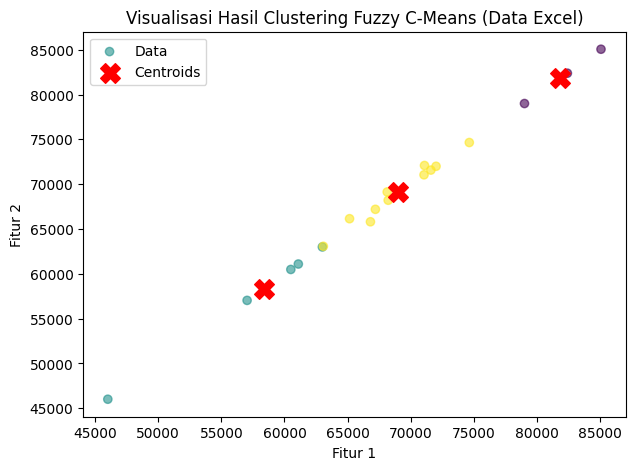

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(dk.iloc[:, 0], dk.iloc[:, 1], c=fcm_labels, cmap='viridis', alpha=0.6, label='Data')
plt.scatter(fcm_centers[:, 0], fcm_centers[:, 1],
            marker='X', s=200, c='red', label='Centroids')

plt.title("Visualisasi Hasil Clustering Fuzzy C-Means (Data Excel)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.legend()
plt.show()